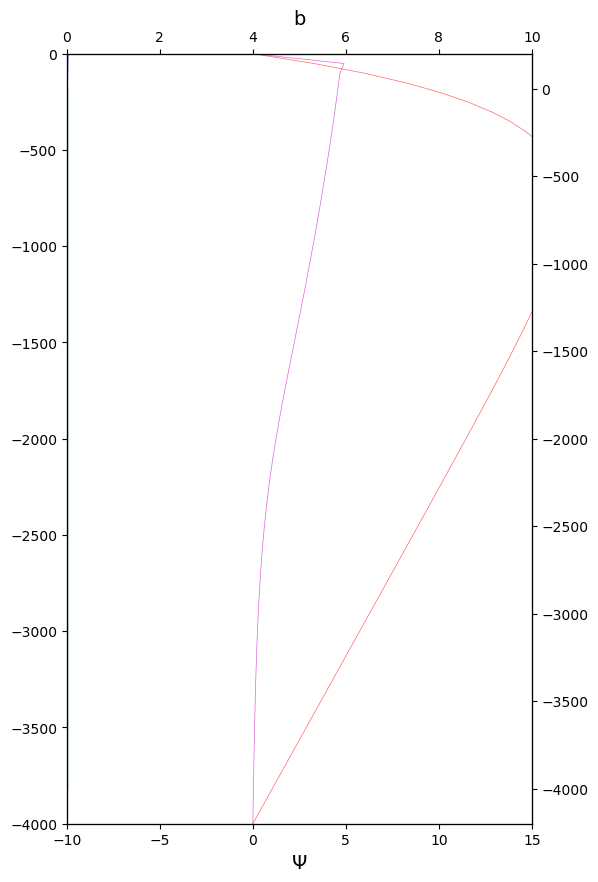

/Users/anb7/pymoc/src/pymoc/modules/SO_ML.py:201: RuntimeWarning: overflow encountered in multiply
  dbdt_ad[1:-1][indneg] = -self.Psi_s[1:-1][indneg] * 1e6 * (
/Users/anb7/pymoc/src/pymoc/modules/SO_ML.py:396: RuntimeWarning: invalid value encountered in multiply
  dbdt_flux = self.surflux / self.h + self.rest_mask * self.v_pist / self.h * (


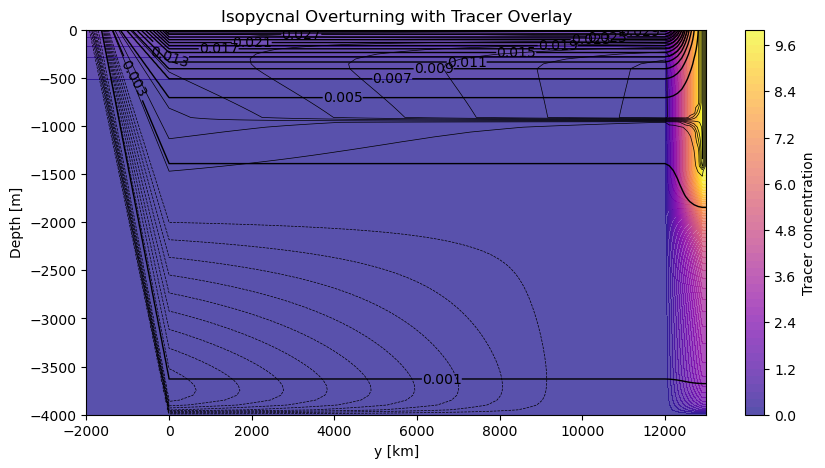

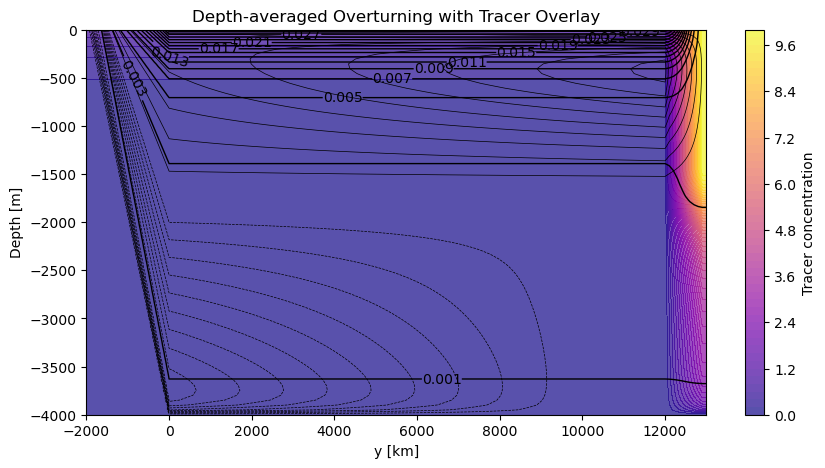

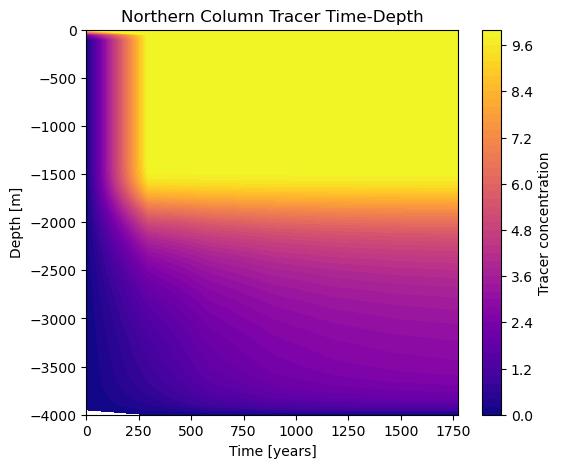

In [2]:
""""
Two-column overturning model with passive tracer release in the north,
with consistent tracer advection (vertical, convective, horizontal)
applied wherever buoyancy is advected.

Key points enforced here:
 - Surface is z[-1] (0 m). Bottom is z[0] (-4000 m).
 - All buoyancy transport operations that act in the Columns are also
   applied to tracer: vertical adv/diff, convective mixing, and horizontal
   advection (horadv_tracer) are executed by passing the same coupling
   inputs (vdx_in, b_in, tracer_in) into Column.timestep.
 - Horizontal coupling between the north and the basin is computed from
   the AMOC surface transport (AMOC.Psi[-1], in Sv) and used to build a
   per-height inflow profile vdx_in (units m^2/s) that is passed to both
   columns each dt so that horadv_tracer runs and transports tracer.
 - The Southern Ocean mixed-layer tracer is advanced by so_ml.advdiff
   at the same cadence used for the MOC updates.
 - Tracer is injected as a surface pulse into the northern column after
   the equilibration phase and then the model runs for another 500 years.

Notes you should verify for your environment before running:
 - AMOC.Psi[-1] is the surface/interface transport (Sv) connecting the basin
   and northern box in your Psi_Thermwind implementation. If your AMOC
   uses a different index for the interface transport, change the index
   used for Q_interface accordingly.
 - Column.Area may be a scalar or callable; here we treat it as callable
   via Column.Akappa/Area usage inside Column routines already; we build
   an area weighting step only if Area varies with z.
"""

from pymoc.modules import Psi_Thermwind, Psi_SO, Column, SO_ML
from pymoc.plotting import Interpolate_channel
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

# -------------------------
# Model parameters / setup
# -------------------------
bs = 0.03
bs_north = 0.004
bmin = 0.0

l = 2.e6
y = np.asarray(np.linspace(0, l, 40))
tau = 0.13
bs_SO = (bs - bmin) * (y / y[-1])**2 + bmin

A_basin = 6e13
A_north = A_basin / 50.0

dt = 86400 * 30
MOC_up_iters = int(np.floor(2. * 360 * 86400 / dt))
plot_iters = int(np.ceil(300 * 360 * 86400 / dt))
total_iters = int(np.ceil(3000 * 360 * 86400 / dt))
# kappa = 2e-5

def kappaeff(z): # effective diffusivity profile with tapering in BBL
            return 1.0*( 1e-4*(1.1-np.tanh(np.maximum(z+2000.,0)/1000. + np.minimum(z+2000.,0)/1300.))
                    *(1.-np.maximum(-4000.-z+600.,0.)/600.)**2 )



# tracer_profile = y /y[-1] 


# vertical grid (surface = 0 at z[-1])
z = np.asarray(np.linspace(-4000, 0, 80))

def b_basin(zlev):
    return bs * np.exp(zlev / 300.)

def b_north(zlev):
    return bs_north * np.exp(zlev / 300.)

# -------------------------
# Create model components
# -------------------------
AMOC = Psi_Thermwind(z=z, b1=b_basin, b2=b_north, f=1e-4)
AMOC.solve()
[Psi_iso_b, Psi_iso_n] = AMOC.Psibz()

SO = Psi_SO(
    z=z,
    y=y,
    b=b_basin(z),
    bs=bs_SO,
    tau=tau,
    f=1e-4,
    L=5e6,
    KGM=1000.,
    c=0.1,
    bvp_with_Ek=True,
)
SO.solve()

so_ml = SO_ML(
    y=y,
    Ks=1000.,
    h=50.,
    L=5e6,
    surflux=0.0,
    rest_mask=0.0,
    b_rest=bs_SO,
    v_pist=1.5 / 86400.0,
    bs=bs_SO.copy(),
)
so_ml.tracer[:] = 0.0

basin = Column(z=z, kappa=kappaeff, Area=A_basin, b=b_basin, bs=bs, bbot=bmin)
north = Column(z=z, kappa=kappaeff, Area=A_north, b=b_north, bs=bs_north, bbot=bmin)

basin.tracer[:] = 0.0
north.tracer[:] = 0.0

tracer_cmap = plt.cm.plasma
tracer_vmin = 0.0
tracer_vmax = 10.0

# layer thicknesses (robust)
dz = np.empty_like(z, dtype=float)
dz[1:-1] = 0.5 * (z[2:] - z[:-2])
dz[0] = z[1] - z[0]
dz[-1] = z[-1] - z[-2]
dz = np.abs(dz)  # thickness positive

# helper to compute vdx_in profile from a scalar interface transport Q [m3/s]
def make_vdx_profile_from_Q(Q, z, dz, Area):
    """
    Convert total interface transport Q [m3/s] into a per-height
    vdx_in profile (units m2/s) defined on vertical grid z such that
    integral(vdx_in * dz) = Q / Area_mean (or Q distributed per-height).
    Simpler: distribute Q evenly per unit height so that sum(vdx*dz)=Q.
    """
    total_thickness = np.sum(dz)
    if total_thickness <= 0:
        total_thickness = 1.0
    # vdx integrated over dz must equal Q => vdx = Q / total_thickness (same for all heights)
    vdx_profile = np.ones_like(z, dtype=float) * (Q / total_thickness)
    return vdx_profile

# -------------------------
# Plot setup (time-iteration small figure)
# -------------------------
fig = plt.figure(figsize=(6, 10))
ax1 = fig.add_subplot(111)
ax2 = ax1.twiny()
plt.ylim((-4e3, 0))
ax1.set_xlim((-10, 15))
ax2.set_xlim((-0.02, 0.03))
ax1.set_xlabel('$\\Psi$', fontsize=14)
ax2.set_xlabel('b', fontsize=14)

# -------------------------
# Run equilibration phase (now with horizontal coupling enabled each dt)
# -------------------------
for ii in range(total_iters):
    # compute effective vertical transports using isopycnal overturning
    wAb = (Psi_iso_b - SO.Psi) * 1e6
    wAN = -Psi_iso_n * 1e6

    # compute interface transport from AMOC surface streamfunction (Sv -> m3/s)
    # NOTE: AMOC.Psi[-1] is assumed to be the surface/interface transport; adjust index if needed.
    Q_interface = AMOC.Psi[-1] * 1e6

    # build vdx profiles to pass into Column.timestep so horadv_tracer runs
    vdx_basin_in = make_vdx_profile_from_Q(Q_interface, z, dz, basin.Area)
    vdx_north_in = -vdx_basin_in  # opposite sign for northern column inflow (drain/outflow)

    # pick donor profiles for upwind horizontal advection (b_in, tracer_in)
    if Q_interface > 0:
        # flow from north -> basin (inflow into basin), donor is north
        b_in_for_basin = north.b.copy()
        tracer_in_for_basin = north.tracer.copy()
        b_in_for_north = north.b.copy()
        tracer_in_for_north = north.tracer.copy()
    else:
        # flow from basin -> north (inflow into north), donor is basin
        b_in_for_basin = basin.b.copy()
        tracer_in_for_basin = basin.tracer.copy()
        b_in_for_north = basin.b.copy()
        tracer_in_for_north = basin.tracer.copy()

    # timestep columns; Column.timestep will call vertadvdiff, convect (if do_conv=True),
    # vertadvdiff_tracer, convect_tracer, and horadv_tracer when vdx_in + tracer_in provided
    basin.timestep(
        wA=wAb,
        dt=dt,
        do_conv=False,
        vdx_in=vdx_basin_in,
        b_in=b_in_for_basin,
        tracer_in=tracer_in_for_basin,
    )

    north.timestep(
        wA=wAN,
        dt=dt,
        do_conv=True,
        vdx_in=vdx_north_in,
        b_in=b_in_for_north,
        tracer_in=tracer_in_for_north,
    )

    # Update overturning and Southern Ocean at coarser cadence
    if ii % MOC_up_iters == 0:
        AMOC.update(b1=basin.b, b2=north.b)
        AMOC.solve()
        [Psi_iso_b, Psi_iso_n] = AMOC.Psibz()

        SO.update(b=basin.b)
        SO.solve()

        # advance the tracer-capable mixed layer for the same accumulated dt
        dt_SO = MOC_up_iters * dt
        so_ml.advdiff(b_basin=basin.b, Psi_b=SO.Psi, dt=dt_SO, tracer_basin=basin.tracer)

    # interactive plotting
    if ii % plot_iters == 0:
        ax1.plot(AMOC.Psi, AMOC.z, linewidth=0.5, color='r', alpha=0.6)
        ax1.plot(SO.Psi, SO.z, linewidth=0.5, color='m', alpha=0.6)
        ax2.plot(basin.b, basin.z, linewidth=0.5, color='b', alpha=0.6)
        ax2.plot(north.b, north.z, linewidth=0.5, color='c', alpha=0.6)

        # overlay north tracer on twin axis of ax2
        if not hasattr(ax2, "_tracer_twin"):
            ax2._tracer_twin = ax2.twinx()
        ax2._tracer_twin.plot(north.tracer, north.z, color='g', linewidth=1.0, alpha=0.9)
        ax2._tracer_twin.set_xlim((tracer_vmin, tracer_vmax))

        plt.pause(0.01)

# -------------------------
# After equilibration: final diagnostic plot (same style as original)
# -------------------------
ax1.plot(AMOC.Psi, AMOC.z, linewidth=2, color='r')
ax1.plot(SO.Psi, SO.z, linewidth=2, color='m')
if hasattr(SO, 'Psi_Ek'):
    ax1.plot(SO.Psi_Ek, SO.z, linewidth=1, color='m', linestyle='--')
if hasattr(SO, 'Psi_GM'):
    ax1.plot(SO.Psi_GM, SO.z, linewidth=1, color='m', linestyle=':')
ax2.plot(basin.b, basin.z, linewidth=2, color='b')
ax2.plot(north.b, north.z, linewidth=2, color='c')
ax1.plot(0.0 * AMOC.z, AMOC.z, linewidth=0.5, color='k')

# -------------------------
# Inject tracer at the northern surface (surface index = -1)
# -------------------------
# Build normalized tracer profile: 0 at 6000 km, 1 at northernmost point
tracer_profile = np.clip((y - 6.0e6) / (y[-1] - 6.0e6), 0, 1)

# Apply to the Southern Ocean mixed layer (latitudinal gradient)
so_ml.tracer[:] = 0.0

# Inject into the northern column at the surface (z[-1])
# Use the northernmost value (1.0) for the surface concentration
north.add_tracer(amount=10*tracer_profile[-1], depth_range=None, as_concentration=True)

# Basin column remains at 0 (equator side)
basin.add_tracer(amount=tracer_profile[0], depth_range=None, as_concentration=True)






# run length after injection: 500 years
years_after = 2000

iters_after = int(np.ceil(years_after * 365.0 * 86400.0 / dt))

snapshot_interval = plot_iters
tracer_snapshots = []

# -------------------------
# Build static channel/basin/north grids for final plotting (use bs_SO for channel)
# -------------------------
bint = Interpolate_channel(y=y, z=z, bs=bs_SO, bn=basin.b)
bsouth = bint.gridit()

ybasin = np.linspace(200., 12000., 60)
bbasin = np.tile(basin.b, (len(ybasin), 1))

ynorth = np.linspace(12100., 13000., 10)
bnorth = np.zeros((len(ynorth), len(z)))
for iz in range(len(z)):
    bnorth[:, iz] = interp1d(
        [11900., 12000., 12900., 13000.],
        [basin.b[iz], basin.b[iz], north.b[iz], north.b[iz]],
        kind='quadratic'
    )(ynorth)

ynew = np.concatenate(((y - l) / 1e3, ybasin, ynorth))
bnew = np.concatenate((bsouth, bbasin, bnorth))

psiarray_iso = np.zeros((len(ynew), len(z)))
psiarray_z = np.zeros((len(ynew), len(z)))
for iy in range(1, len(y)):
    psiarray_iso[iy, :] = np.interp(bnew[iy, :], basin.b, SO.Psi)
    psiarray_z[iy, :] = psiarray_iso[iy, :]
for iy in range(len(y), len(y) + len(ybasin)):
    psiarray_iso[iy, :] = (ynew[iy] * AMOC.Psibz()[0] + (10000. - ynew[iy]) * SO.Psi) / 10000.
    psiarray_z[iy, :] = (ynew[iy] * AMOC.Psi + (10000. - ynew[iy]) * SO.Psi) / 10000.
for iy in range(len(y) + len(ybasin), len(ynew)):
    psiarray_iso[iy, :] = np.interp(bnew[iy, :], AMOC.bgrid, AMOC.Psib())
    psiarray_z[iy, :] = ((13000. - ynew[iy]) * AMOC.Psi) / 1000.
psiarray_iso[-1, :] = 0.0

blevs = np.arange(0.001, 0.03, 0.002)
plevs = np.concatenate((np.arange(-15., -0.4, 0.5), np.arange(1., 16., 1.)))

# -------------------------
# Second phase: propagate tracer for iters_after steps with identical coupling
# -------------------------
for jj in range(iters_after):
    wAb = (Psi_iso_b - SO.Psi) * 1e6
    wAN = -Psi_iso_n * 1e6

    Q_interface = AMOC.Psi[-1] * 1e6
    vdx_profile_abs = make_vdx_profile_from_Q(abs(Q_interface), z, dz, basin.Area)
    
    if Q_interface > 0:
        # North -> Basin
        vdx_basin_in = vdx_profile_abs                  # basin receives inflow
        vdx_north_in = vdx_profile_abs                  # north receives inflow from basin's return path
        b_in_for_basin = north.b.copy()
        tracer_in_for_basin = north.tracer.copy()
        b_in_for_north = basin.b.copy()
        tracer_in_for_north = basin.tracer.copy()
    else:
        # Basin -> North
        vdx_north_in = vdx_profile_abs
        vdx_basin_in = vdx_profile_abs
        b_in_for_north = basin.b.copy()
        tracer_in_for_north = basin.tracer.copy()
        b_in_for_basin = north.b.copy()
        tracer_in_for_basin = north.tracer.copy()


    basin.timestep(
        wA=wAb,
        dt=dt,
        do_conv=False,
        vdx_in=vdx_basin_in,
        b_in=b_in_for_basin,
        tracer_in=tracer_in_for_basin,
    )

    north.timestep(
        wA=wAN,
        dt=dt,
        do_conv=True,
        vdx_in=vdx_north_in,
        b_in=b_in_for_north,
        tracer_in=tracer_in_for_north,
    )

    if jj % MOC_up_iters == 0:
        AMOC.update(b1=basin.b, b2=north.b)
        AMOC.solve()
        [Psi_iso_b, Psi_iso_n] = AMOC.Psibz()

        SO.update(b=basin.b)
        SO.solve()

        dt_SO = MOC_up_iters * dt
        so_ml.advdiff(b_basin=basin.b, Psi_b=SO.Psi, dt=dt_SO, tracer_basin=basin.tracer)

    if jj % plot_iters == 0:
        ax1.plot(AMOC.Psi, AMOC.z, linewidth=0.5, color='r', alpha=0.3)
        ax1.plot(SO.Psi, SO.z, linewidth=0.5, color='m', alpha=0.3)
        ax2.plot(basin.b, basin.z, linewidth=0.5, color='b', alpha=0.3)
        ax2.plot(north.b, north.z, linewidth=0.5, color='c', alpha=0.3)

        if not hasattr(ax2, "_tracer_twin"):
            ax2._tracer_twin = ax2.twinx()
        ax2._tracer_twin.plot(north.tracer, north.z, color='g', linewidth=1.0, alpha=0.9)
        ax2._tracer_twin.set_xlim((tracer_vmin, tracer_vmax))

        plt.pause(0.01)

    if jj % snapshot_interval == 0:
        tracer_snapshots.append((basin.tracer.copy(), north.tracer.copy(), so_ml.tracer.copy()))

# -------------------------
# Build tracer field to overlay on 2D plots (channel/basin/north)
# -------------------------
tchannel = np.tile(basin.tracer, (len(y), 1))
tbasin = np.tile(basin.tracer, (len(ybasin), 1))

tnorth = np.zeros((len(ynorth), len(z)))
for iz in range(len(z)):
    tnorth[:, iz] = interp1d(
        [11900., 12000., 12900., 13000.],
        [basin.tracer[iz], basin.tracer[iz], north.tracer[iz], north.tracer[iz]],
        kind='linear'
    )(ynorth)

tnew = np.concatenate((tchannel, tbasin, tnorth))
# tchannel = np.tile(basin.tracer, (len(y), 1))
# tbasin   = np.tile(basin.tracer, (len(ybasin), 1))

# # Continuous gradient north of 6000 km
# tracer_profile_north = np.clip((ynorth*1e3 - 6.0e6) / (y[-1] - 6.0e6), 0, 1)

# tnorth = np.tile(tracer_profile_north[:, None], (1, len(z)))  # same profile across depth

# tnew = np.concatenate((tchannel, tbasin, tnorth))
# -------------------------
# Final overlay plots
# -------------------------
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)
CS = ax.contour(ynew, z, bnew.transpose(), levels=blevs, colors='k', linewidths=1.0)
ax.clabel(CS, fontsize=10)
ax.contour(ynew, z, psiarray_iso.transpose(), levels=plevs, colors='k', linewidths=0.5)
TC = ax.contourf(ynew, z, tnew.transpose(), levels=50, cmap=tracer_cmap, vmin=tracer_vmin, vmax=tracer_vmax, alpha=0.7)
plt.colorbar(TC, label='Tracer concentration')
ax.set_xlabel('y [km]')
ax.set_ylabel('Depth [m]')
ax.set_title('Isopycnal Overturning with Tracer Overlay')

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)
CS2 = ax.contour(ynew, z, bnew.transpose(), levels=blevs, colors='k', linewidths=1.0)
ax.clabel(CS2, fontsize=10)
ax.contour(ynew, z, psiarray_z.transpose(), levels=plevs, colors='k', linewidths=0.5)
TC2 = ax.contourf(ynew, z, tnew.transpose(), levels=50, cmap=tracer_cmap, vmin=tracer_vmin, vmax=tracer_vmax, alpha=0.7)
plt.colorbar(TC2, label='Tracer concentration')
ax.set_xlabel('y [km]')
ax.set_ylabel('Depth [m]')
ax.set_title('Depth-averaged Overturning with Tracer Overlay')

# Hovmoller of northern tracer
if len(tracer_snapshots) > 0:
    times = np.arange(0, len(tracer_snapshots)) * (snapshot_interval * dt) / (365.0 * 86400.0)
    tseries = np.array([snap[1] for snap in tracer_snapshots])

    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111)
    cf = ax.contourf(times, z, tseries.T, levels=50, cmap=tracer_cmap, vmin=tracer_vmin, vmax=tracer_vmax)
    plt.colorbar(cf, label='Tracer concentration')
    ax.set_xlabel('Time [years]')
    ax.set_ylabel('Depth [m]')
    ax.set_title('Northern Column Tracer Time-Depth')

plt.show()